# Natural Language Processing with Disaster Tweets - Week 4 Project





The goal of this project is to predict whether or not a particular tweet is related to a real disaster. This is confounded in the fact that sometimes people use "disastrous" language to describe the sandwich they just "DEMOLISHED". 

In our case if it's a real disaster, we predict a 1, and a zero if its not.

# Data format
Our data is split into training and test datasets. 


### Columns:
ID - A unique identifier.

Keyword - A word of interest from the tweet - though it can be blank. 

Location - Where the tweet was sent from - can also be blank.

Text - The full text of the tweet.

Target - Only in the training dataset - we denote whether a tweet is about a real disaster. It's a boolean.

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder as OHE
from sklearn.metrics import classification_report
import sys
print(sys.path)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Dense, LSTM, BatchNormalization, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy as CC
from tensorflow.keras.activations import relu, softmax
from tensorflow.keras.initializers import he_uniform, glorot_uniform
from tensorflow.keras.metrics import AUC
from tensorflow.keras import Model
from tensorflow.keras.regularizers import l2


['c:\\Users\\diego\\AppData\\Local\\Programs\\Python\\Python312\\python312.zip', 'c:\\Users\\diego\\AppData\\Local\\Programs\\Python\\Python312\\DLLs', 'c:\\Users\\diego\\AppData\\Local\\Programs\\Python\\Python312\\Lib', 'c:\\Users\\diego\\AppData\\Local\\Programs\\Python\\Python312', '', 'C:\\Users\\diego\\AppData\\Roaming\\Python\\Python312\\site-packages', 'C:\\Users\\diego\\AppData\\Roaming\\Python\\Python312\\site-packages\\win32', 'C:\\Users\\diego\\AppData\\Roaming\\Python\\Python312\\site-packages\\win32\\lib', 'C:\\Users\\diego\\AppData\\Roaming\\Python\\Python312\\site-packages\\Pythonwin', 'c:\\Users\\diego\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages']


In [14]:

train = pd.read_csv('C:/Users/diego/GradSchool/DeepLearningIntro/WeekFour/train.csv')
test = pd.read_csv('C:/Users/diego/GradSchool/DeepLearningIntro/WeekFour/test.csv')
print('Number of Training Records:',len(train))
print('Number of Test Records:', len(test))

print("Number of Disaster Records in Training Data:",len(train.query('target ==1')))
print("Number of Non-Disaster Records in Training Data:",len(train.query('target ==0')))

Number of Training Records: 7613
Number of Test Records: 3263
Number of Disaster Records in Training Data: 3271
Number of Non-Disaster Records in Training Data: 4342


# Exploratory Data Analysis
We have to do something about the blank keyword and location in our data as it would break our preprocessing pipeline when vectorizing text and/or concatenating features.

This is really easy to do with pandas.

Note: Earlier I filled the na's with the term "missing" before deciding on a model architecture as LSTM. Since LSTM requires one single sequence per record - we have to concatenate - and it makes a lot more sense to concatenate a blank string '' rather than the word 'missing'.

In [15]:
print(train['keyword'].isnull().sum())
print(train['location'].isnull().sum())
print(test['keyword'].isnull().sum())
print(test['location'].isnull().sum())

train['keyword'] = train['keyword'].fillna('')
train['location'] = train['location'].fillna('')
test['keyword'] = test['keyword'].fillna('')
test['location'] = test['location'].fillna('')

print(train['keyword'].isna().sum())
print(train['location'].isna().sum())
print(test['keyword'].isna().sum())
print(test['location'].isna().sum())

61
2533
26
1105
0
0
0
0


Let's check some other things out. We'll take a look at target distribution and text length/quality.

In [16]:
train['target'].value_counts(normalize = True)

target
0    0.57034
1    0.42966
Name: proportion, dtype: float64

This is a mild class imbalance but not necessarily the end of the world. It will be important to consider metrics other than accuracy as it might predict "non-disaster" incorrectly and miss true positives.

Instead, let's also consider the precision, recall, F1 score and ROC AUC when its time to analyze.

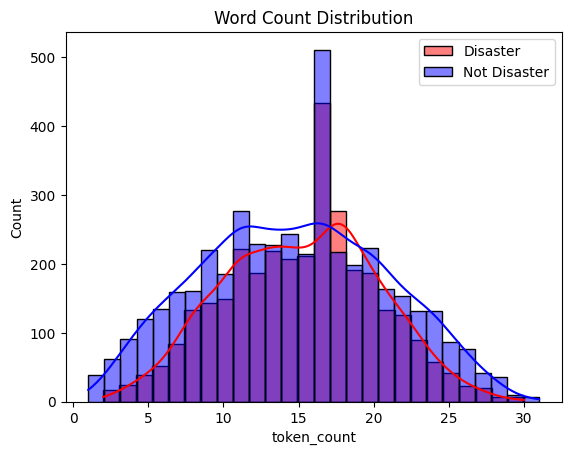

In [17]:
train['text_length'] = train['text'].apply(len)
train['token_count'] = train['text'].apply(lambda x: len(x.split()))


sns.histplot(train[train['target']==1]['token_count'], color='red', label='Disaster', kde=True)
sns.histplot(train[train['target']==0]['token_count'], color='blue', label='Not Disaster', kde=True)
plt.legend()
plt.title("Word Count Distribution")
plt.show()

There does not appear to be a significant difference in word counts for disaster vs non disaster texts.

Let's do some more pre-processing.

In [23]:
train['keyword'] = train['keyword'].fillna('')
train['location'] = train['location'].fillna('')
train['full_text'] = train['keyword'] + ' ' + train['location'] + ' ' + train['text']

test['keyword'] = test['keyword'].fillna('')
test['location'] = test['location'].fillna('')
test['full_text'] = test['keyword'] + ' ' + test['location'] + ' ' + test['text']

# Model Architecture
I will be using LSTM for this task. LSTMS are good for handling sequential data list text, since the order of words matter in regards to meaning. It is also good for noting long-term dependencies and is capable of maintaining a "memory" of previous inputs. This allows it to get a better context.

However, since we are doing LSTM rather than logistic regression, random forest or some other supervised learning method, we will need to consolidate all our strings together into a full text.

Because of this, we'll actually have to change our pre-processing from earlier, because we would rather treat the blanks as '' rather than the word 'missing' over and over again. 


# Tokenizer
LSTM - like most neural nets - require input sequences to be the same length because they work on fixed-size tensors. 

Our input is a matrix! And so if we tried to do matrix multiplication between sequences of different lengths, we would not get a nice square standard matrix. 

Since our graph shows us that the longest tweet is about 30 words long, we will set our max sequence length to 33 so that we can account for the full text- location and keyword being added of course. 

In [ ]:

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences
MAX_NUM_WORDS = 10000   # Vocabulary size
MAX_SEQ_LENGTH = 33    # Max tweet length in words

tokenizer = Tokenizer(num_words=MAX_NUM_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(train['full_text'])

X_train_seq = tokenizer.texts_to_sequences(train['full_text'])
X_test_seq = tokenizer.texts_to_sequences(test['full_text'])

#Sequence Padding
X_train = pad_sequences(X_train_seq, maxlen=MAX_SEQ_LENGTH, padding='post', truncating='post')
X_test = pad_sequences(X_test_seq, maxlen=MAX_SEQ_LENGTH, padding='post', truncating='post')

y_train = train['target'].values

## LSTM Model
Time to build our actual model

In [25]:
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dense, Dropout

model = Sequential()
model.add(Embedding(input_dim=MAX_NUM_WORDS,output_dim = 64,input_length=MAX_SEQ_LENGTH))
model.add(LSTM(64,return_sequences = False))
model.add(Dropout(0.5))
model.add(Dense(1,activation = 'sigmoid'))

model.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics=['accuracy', 'Precision', 'Recall', 'AUC'])
model.summary()

c:\Users\diego\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.fit(X_train,y_train, epochs = 5, batch_size = 32, validation_split = 0.2)

Epoch 1/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - AUC: 0.9855 - Precision: 0.9682 - Recall: 0.9086 - accuracy: 0.9483 - loss: 0.1362 - val_AUC: 0.9914 - val_Precision: 0.9938 - val_Recall: 0.9027 - val_accuracy: 0.9521 - val_loss: 0.1161
Epoch 2/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - AUC: 0.9917 - Precision: 0.9723 - Recall: 0.9305 - accuracy: 0.9591 - loss: 0.1066 - val_AUC: 0.9878 - val_Precision: 0.9479 - val_Recall: 0.9238 - val_accuracy: 0.9409 - val_loss: 0.1419
Epoch 3/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - AUC: 0.9918 - Precision: 0.9607 - Recall: 0.9362 - accuracy: 0.9577 - loss: 0.1048 - val_AUC: 0.9860 - val_Precision: 0.9857 - val_Recall: 0.8759 - val_accuracy: 0.9363 - val_loss: 0.1621
Epoch 4/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - AUC: 0.9965 - Precision: 0.9806 - Recall: 0.9502 - accuracy: 0.9709 - loss: 0.0685 - val_AUC: 0.9838 - val_Precision: 0.9264 - val_Recall: 0.9238 - val_accuracy: 0.9304 - val_loss: 0.1565
Epoch 5/5
191/191 ━━━━━━━━━━━━━━━━━━

In [27]:
y_test_pred = model.predict(X_test)
y_test_labels = (y_test_pred >0.5).astype(int)


102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
submission = test[['id']].copy()
submission['target'] = y_test_labels
submission.to_csv('submission.csv', index=False)

# Results, Analysis and Conclusion
The model performs well on all counts - it's likely that there may be some overfitting as the validation recall starts to drop on Epoch 3. The high AUC score shows that there's good separation between classes.

Another point of concern is the Validation loss increasing slightly after epoch 1 while accuracy stays high - possible a sign of overfitting. 

Upon submitting this to Kaggle, I got a score of 0.77076. Not bad for a first try!

To improve this we could implement some early stoppage based on monitoring validation loss. Lets try that next.



In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

#early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
model.fit(X_train,y_train, epochs = 5, batch_size = 32, validation_split = 0.2)

y_test_pred = model.predict(X_test)
y_test_labels = (y_test_pred >0.5).astype(int)

submission = test[['id']].copy()
submission['target'] = y_test_labels
submission.to_csv('submission2.csv', index=False)

Epoch 1/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - AUC: 0.9977 - Precision: 0.9815 - Recall: 0.9619 - accuracy: 0.9763 - loss: 0.0542 - val_AUC: 0.9725 - val_Precision: 0.9187 - val_Recall: 0.9083 - val_accuracy: 0.9199 - val_loss: 0.2444
Epoch 2/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - AUC: 0.9976 - Precision: 0.9767 - Recall: 0.9698 - accuracy: 0.9786 - loss: 0.0463 - val_AUC: 0.9596 - val_Precision: 0.9083 - val_Recall: 0.8942 - val_accuracy: 0.9087 - val_loss: 0.3088
Epoch 3/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - AUC: 0.9983 - Precision: 0.9792 - Recall: 0.9796 - accuracy: 0.9830 - loss: 0.0427 - val_AUC: 0.9663 - val_Precision: 0.9017 - val_Recall: 0.9055 - val_accuracy: 0.9100 - val_loss: 0.2717
Epoch 4/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - AUC: 0.9984 - Precision: 0.9853 - Recall: 0.9725 - accuracy: 0.9823 - loss: 0.0407 - val_AUC: 0.9616 - val_Precision: 0.8823 - val_Recall: 0.9196 - val_accuracy: 0.9054 - val_loss: 0.3333
Epoch 5/5
191/191 ━━━━━━━━━━━━━━━━━━

My 2nd submission with early stoppage implemented actually performed slightly worse, with a score of 0.75942. Likely that the effects for validation loss are too minor to have any meaningful effect on my model.

Let's try removing some of the features and just training this on the original text itself, no keywords or location.

In [32]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences
MAX_NUM_WORDS = 10000   # Vocabulary size
MAX_SEQ_LENGTH = 30   # Max tweet length in words

tokenizer = Tokenizer(num_words=MAX_NUM_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(train['text'])

X_train_seq = tokenizer.texts_to_sequences(train['text'])
X_test_seq = tokenizer.texts_to_sequences(test['text'])

#Sequence Padding
X_train = pad_sequences(X_train_seq, maxlen=MAX_SEQ_LENGTH, padding='post', truncating='post')
X_test = pad_sequences(X_test_seq, maxlen=MAX_SEQ_LENGTH, padding='post', truncating='post')

y_train = train['target'].values

In [34]:
from tensorflow.keras.callbacks import EarlyStopping

#early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
model.fit(X_train,y_train, epochs = 5, batch_size = 32, validation_split = 0.2)

y_test_pred = model.predict(X_test)
y_test_labels = (y_test_pred >0.5).astype(int)

submission = test[['id']].copy()
submission['target'] = y_test_labels
submission.to_csv('submission3.csv', index=False)

Epoch 1/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - AUC: 0.9848 - Precision: 0.9670 - Recall: 0.9417 - accuracy: 0.9623 - loss: 0.1322 - val_AUC: 0.7945 - val_Precision: 0.7914 - val_Recall: 0.6474 - val_accuracy: 0.7564 - val_loss: 0.7256
Epoch 2/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - AUC: 0.9875 - Precision: 0.9678 - Recall: 0.9356 - accuracy: 0.9610 - loss: 0.1181 - val_AUC: 0.7828 - val_Precision: 0.7444 - val_Recall: 0.6615 - val_accuracy: 0.7367 - val_loss: 0.9625
Epoch 3/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - AUC: 0.9894 - Precision: 0.9662 - Recall: 0.9362 - accuracy: 0.9591 - loss: 0.1128 - val_AUC: 0.7884 - val_Precision: 0.6718 - val_Recall: 0.7419 - val_accuracy: 0.7111 - val_loss: 0.8677
Epoch 4/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - AUC: 0.9932 - Precision: 0.9632 - Recall: 0.9561 - accuracy: 0.9666 - loss: 0.0868 - val_AUC: 0.7737 - val_Precision: 0.6390 - val_Recall: 0.7941 - val_accuracy: 0.6953 - val_loss: 1.0785
Epoch 5/5
191/191 ━━━━━━━━━━━━━━━━━━

We only get a score of 0.75084 on the 3rd attempt. LSTMs seem to be pretty good. 

Most likely, the problem has to do with my level of data cleaning - if I were to remove duplicate words and filler words that dont add critical information, the model would perform a fair bit better. 

